In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, OneHotEncoder  #SCALE NUMARICAL DATA, COVERT CATEGORICAL DATA INTO NUMBERS.
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline #run model & preprocessing in one flow
from sklearn.ensemble import RandomForestClassifier # combination of multiple decision tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report #true & fales prediction, precision recall, f1 score.
import pickle 


In [2]:
#Load dataset
df = pd.read_csv("synthetic_bank_churn_dataset.csv")
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (1000, 14)
   CustomerID  Gender  Age Geography  Tenure    Balance  NumOfProducts  \
0    10000001    Male   34     Spain       0   46960.71              2   
1    10000002  Female   26   Germany       6  179947.86              3   
2    10000003    Male   50    France       7  216733.37              4   
3    10000004    Male   37   Germany       2  113486.71              3   
4    10000005    Male   30   Germany       4  205358.00              1   

   HasCrCard  IsActiveMember  EstimatedSalary  AverageMonthlyBalance  \
0          1               0        117519.92               46960.71   
1          1               1         79386.31               25706.84   
2          0               1        129936.76               27091.67   
3          0               0         34850.83               37828.90   
4          1               0         53195.94               41071.60   

   ProductsPerCustomer  SalaryToBalanceRatio  Exited  
0                 2.00                  2

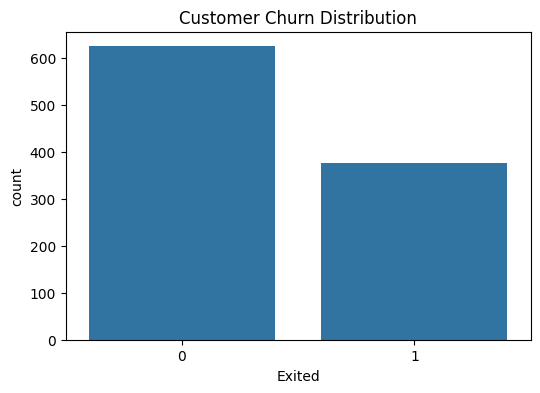

In [3]:
#Exploratory Data Analysis (EDA)
plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=df)
plt.title("Customer Churn Distribution")
plt.show()

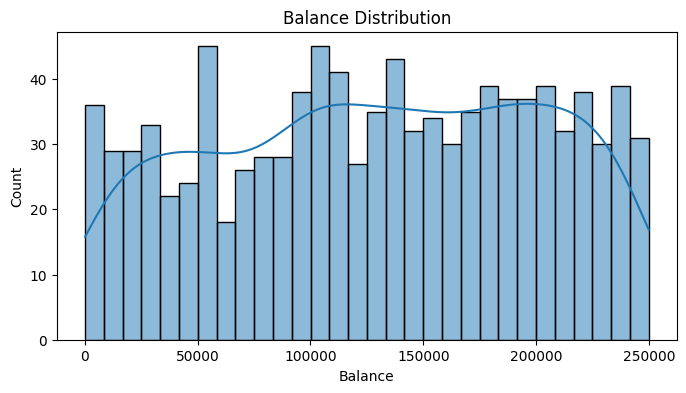

In [4]:
plt.figure(figsize=(8,4))
sns.histplot(df['Balance'], bins=30, kde=True)
plt.title("Balance Distribution")
plt.show()

In [5]:
#Features and target
X = df.drop(['CustomerID', 'Exited'], axis=1)
y = df['Exited']

In [6]:
#Identify categorical and numerical columns
cat_cols = ['Gender', 'Geography']
num_cols = [col for col in X.columns if col not in cat_cols]

In [7]:
#Preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

In [8]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
#Pipeline with Random Forest
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=300, random_state=42, max_depth=8))
])

In [10]:
#Train the model
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [11]:
#Evaluate model
y_pred = model_pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.65

Confusion Matrix:
 [[100  25]
 [ 45  30]]

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.80      0.74       125
           1       0.55      0.40      0.46        75

    accuracy                           0.65       200
   macro avg       0.62      0.60      0.60       200
weighted avg       0.64      0.65      0.64       200



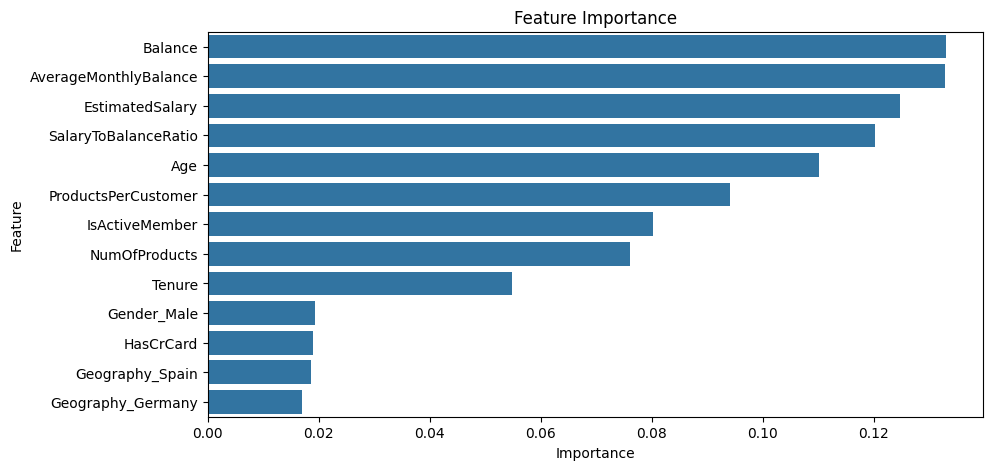

In [12]:
#Feature Importance (for numerical features only)
rf_model = model_pipeline.named_steps['classifier']
features_after_encoding = num_cols + list(model_pipeline.named_steps['preprocessor']
                                         .named_transformers_['cat'].get_feature_names_out(cat_cols))
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features_after_encoding, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Feature Importance")
plt.show()

In [13]:
#Save model
pickle.dump(model_pipeline, open("bank_churn_model.pkl", "wb"))
print("Model saved as 'bank_churn_model.pkl'")

Model saved as 'bank_churn_model.pkl'
